# **Impacto de las Redes Sociales en la Salud Mental de los Adolescentes**

### - **Alumno**: Marco Antonio Chávez Medina

### - **Materia**: Aprendizaje Automático

### - **Objetivo**: Entrenar un modelo de regresión lineal que prediga el nivel de ansiedad (1 - 10) de un adolescente (13 - 19 años), utilizando las diferentes columnas del dataset, como por ejemplo, el tiempo que pasan en las redes sociales, las redes sociales que usan, etc.



# **CRONOGRAMA**

### **1ra entrega**: Descripción del dataset y objetivo

### **2da entrega**: Análisis Estadístico, Selección de Variables y Entrenamiento del Modelo de Regresión

### **3ra entrega**: Entrega final del proyecto, comparando al menos 2 técnicas de entrenamiento

# **REGRESIÓN LINEAL**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Aprendizaje_Automatico/Teen_Mental_Health_Dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Imprimimos informacion general del Dataset
print(df.info())

print('\n', df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB
None

In [ ]:
#Imprimimos algunas estadisticas basicas del dataset
print(df.describe().round(2))

           age  daily_social_media_hours  sleep_hours  \
count  1200.00                   1200.00      1200.00   
mean     15.93                      4.54         6.45   
std       2.02                      2.03         1.44   
min      13.00                      1.00         4.00   
25%      14.00                      2.80         5.20   
50%      16.00                      4.50         6.50   
75%      18.00                      6.30         7.60   
max      19.00                      8.00         9.00   

       screen_time_before_sleep  academic_performance  physical_activity  \
count                   1200.00               1200.00            1200.00   
mean                       1.74                  2.99               1.01   
std                        0.72                  0.58               0.58   
min                        0.50                  2.00               0.00   
25%                        1.10                  2.50               0.50   
50%                        1.8

In [ ]:
#Verificamos si no hay datos faltantes
nulos = df.isnull().sum()

print(nulos[nulos > 0] if nulos.sum() > 0 else 'No hay datos faltantes')

No hay datos faltantes


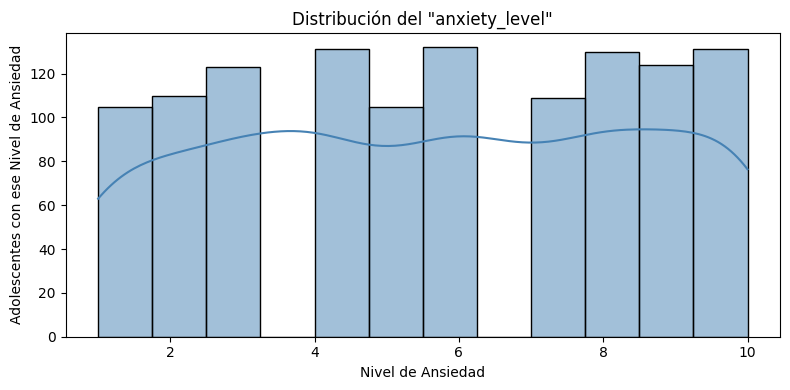

In [ ]:
#Veo como se distribuye mi variable objetivo

plt.figure(figsize=(8, 4))

sns.histplot(df['anxiety_level'], kde=True, color='steelblue')

plt.title('Distribución del "anxiety_level"')
plt.xlabel('Nivel de Ansiedad')
plt.ylabel('Adolescentes con ese Nivel de Ansiedad')
plt.tight_layout()
plt.show()

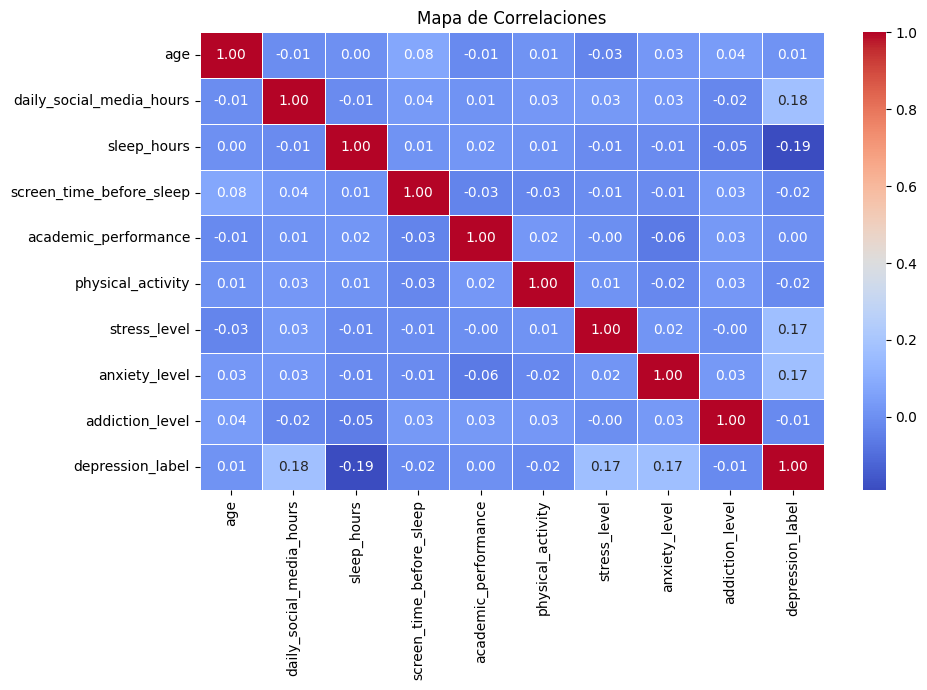



Columnas que no se usaron (porque son de tipo "object"): ['gender', 'platform_usage', 'social_interaction_level']


In [ ]:
#Imprimimos una matriz de correlacion

matriz_corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))

sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title('Mapa de Correlaciones')
plt.tight_layout()
plt.show()

variables_no = []

for feature in df.columns:
    if (df[feature].dtype == object):
      variables_no.append(feature)

print(f'\n\nColumnas que no se usaron (porque son de tipo "object"): {variables_no}')

In [ ]:
#Ahora como vemos que tenemos 3 features de tipo 'object', las voy a transformar

#social_interaction_level (Label Encoding)
mapeo_correcto = {
    'low': 0,
    'medium': 1,
    'high': 2
}

le = LabelEncoder()

df['social_interaction_level'] = df['social_interaction_level'].map(mapeo_correcto)

print(df['social_interaction_level'])

#gender (Label Encoding)
df['gender'] = le.fit_transform(df['gender'])

print('\n', df['gender'])

#platform_usage (OneHot Encoding)
ohe = OneHotEncoder(sparse_output=False)

ohe_array = ohe.fit_transform(df[['platform_usage']])

ohe_cols = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(['platform_usage']))

df = df.drop(columns=['platform_usage']).reset_index(drop=True)
df = pd.concat([df, ohe_cols], axis=1)

print('\n', df['platform_usage_Instagram'], '\n\n', df['platform_usage_TikTok'], '\n\n', df['platform_usage_Both'])

0       0
1       2
2       2
3       1
4       1
       ..
1195    0
1196    2
1197    2
1198    2
1199    1
Name: social_interaction_level, Length: 1200, dtype: int64

 0       1
1       0
2       0
3       1
4       0
       ..
1195    0
1196    1
1197    0
1198    1
1199    0
Name: gender, Length: 1200, dtype: int64

 0       1.0
1       0.0
2       1.0
3       0.0
4       0.0
       ... 
1195    1.0
1196    0.0
1197    0.0
1198    0.0
1199    0.0
Name: platform_usage_Instagram, Length: 1200, dtype: float64 

 0       0.0
1       1.0
2       0.0
3       1.0
4       0.0
       ... 
1195    0.0
1196    0.0
1197    0.0
1198    0.0
1199    1.0
Name: platform_usage_TikTok, Length: 1200, dtype: float64 

 0       0.0
1       0.0
2       0.0
3       0.0
4       1.0
       ... 
1195    0.0
1196    1.0
1197    1.0
1198    1.0
1199    0.0
Name: platform_usage_Both, Length: 1200, dtype: float64


In [ ]:
#Ahora hago la seleccion de mis variables
x = df.drop(columns=['anxiety_level', 'depression_label'])
y = df['anxiety_level']

In [ ]:
#Hago la division de mis datos de entrenamiento y de prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=2006)

print(f"\nEntrenamiento: {x_train.shape[0]}")
print(f"Prueba:        {x_test.shape[0]}")


Entrenamiento: 960
Prueba:        240


In [ ]:
#Creo y entreno el modelo
modelo = LinearRegression()

modelo.fit(x_train, y_train)

LinearRegression()

In [ ]:
#Evaluamos el modelo con algunas metricas
y_pred = modelo.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('Metricas del Modelo\n')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')

Metricas del Modelo

MAE: 2.4742
RMSE: 2.8470
R2: 0.0016


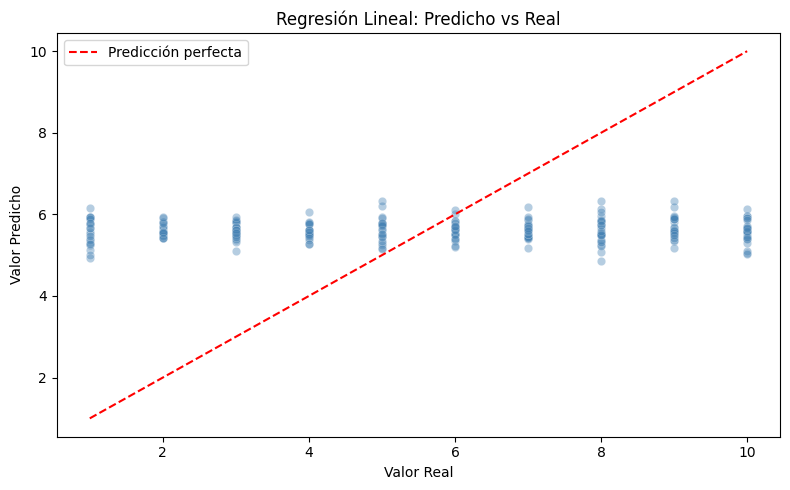

In [ ]:
#Grafico lo predicho vs lo real
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Regresión Lineal: Predicho vs Real')
plt.legend()
plt.tight_layout()
plt.show()

# **RESULTADOS DE LA PRIMERA TÉCNICA DE ENTRENAMIENTO**

### El modelo de regresión lineal predice un valor constante cercano a la media independientemente del valor real, lo que indica que no logró capturar ninguna relación entre las variables. Esto motiva el uso de Random Forest en la siguiente sección.

### De igual manera intenté usar otras features como mis variables predictoras (como: depression_label) pero dan casi los mismos resultados.



```
# Estos resultados son de los que hablo

Métricas del Modelo

MAE: 2.4742 <-- bueno
RMSE: 2.8470 <-- bueno
R2: 0.0016 <-- muy malo (quiere decir que el modelo no explica prácticamente nada)
```



# **RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [ ]:
# Definimos el espacio de búsqueda de hiperparámetros
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV prueba todas las combinaciones usando validación cruzada
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"\nMejor R² promedio en validación cruzada: {grid_search.best_score_:.4f}")

# Reemplazamos rf_model por el mejor modelo encontrado
rf_model = grid_search.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores hiperparámetros encontrados:
{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}

Mejor R² promedio en validación cruzada: -0.0162


In [ ]:
#Hacemos la predicciones y calculamos algunas metricas
y_pred_rf = rf_model.predict(x_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE: ", mae_rf)
print("RMSE: ", rmse_rf)
print("R2: ", r2_rf)

MAE:  2.489120035145303
RMSE:  2.851330145302577
R2:  -0.0013981195252021905


R2 es incluso peor aquí, que en el modelo anterior

In [ ]:
#Vemos la importancia de nuestros features
importances = pd.Series(rf_model.feature_importances_, index=x.columns)
importances = importances.sort_values(ascending=False)

print(importances)

academic_performance        0.186144
daily_social_media_hours    0.167395
sleep_hours                 0.139145
physical_activity           0.125556
screen_time_before_sleep    0.116942
stress_level                0.069645
age                         0.062969
addiction_level             0.061312
social_interaction_level    0.022928
gender                      0.015863
platform_usage_Instagram    0.011328
platform_usage_TikTok       0.011174
platform_usage_Both         0.009599
dtype: float64


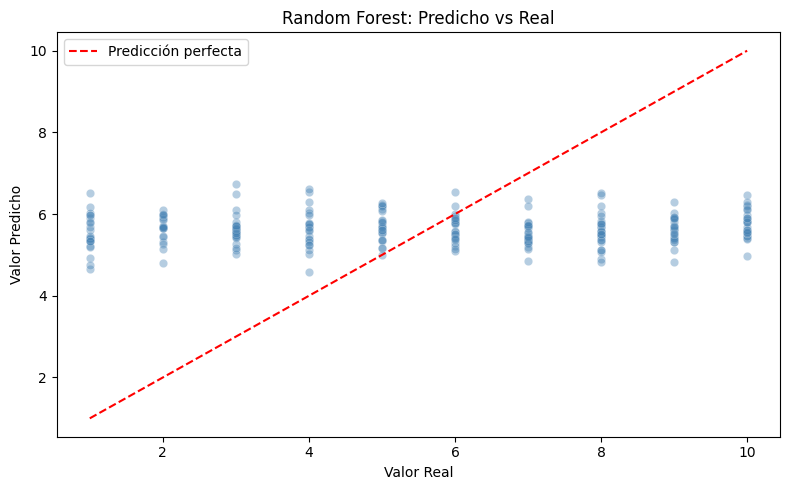

In [ ]:
#Grafica comparativa
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Random Forest: Predicho vs Real')
plt.legend()
plt.tight_layout()
plt.show()

#**CONCLUSIONES**


# Comparación de modelos

| Métrica | Regresión Lineal | Random Forest |
|---|---|---|
| MAE  | 2.4742 | 2.4925 |
| RMSE | 2.8470 | 2.8493 |
| R²   | 0.0016 | 0.0000396 |

Se entrenaron y evaluaron dos modelos para predecir `anxiety_level`: una Regresión Lineal y un Random Forest. Ambos modelos fueron evaluados sobre el mismo conjunto de prueba para garantizar una comparación justa.

# Hallazgos principales

1. **Ningún modelo logró capturar una relación predictiva significativa.** El R² de la Regresión Lineal es casi cero, y el de Random Forest (aún buscando los hiperparámetros) da negativo, lo que indica que las predicciones no son sustancialmente mejores que predecir simplemente el promedio de `anxiety_level` para todos los casos.

2. **El Random Forest no mejoró el desempeño respecto a la Regresión Lineal**, e incluso obtuvo un R² ligeramente menor. Dado que Random Forest puede capturar relaciones no lineales que la regresión lineal no detecta, este resultado sugiere que el problema no es la elección del algoritmo, sino una **falta de señal predictiva en los datos disponibles**.

3. **El análisis de `feature_importances_` del Random Forest refuerza esta conclusión.** Ninguna variable individual mostró una importancia dominante: los valores se distribuyen de forma gradual y pareja entre las 13 features (desde 0.168 hasta 0.014), sin que ninguna se destaque claramente sobre las demás. Cuando existe una relación real entre features y target, es común observar 1 o 2 variables con importancia notablemente más alta que el resto; aquí no se observa ese patrón.

4. **Las gráficas de Predicho vs. Real** muestran que ambos modelos agrupan sus predicciones en una banda estrecha (aproximadamente entre 4.5 y 6.5), independientemente del valor real de `anxiety_level`, en vez de seguir la línea de predicción perfecta.

# Interpretación

Estos resultados, obtenidos con dos algoritmos de naturaleza distinta (uno lineal y uno basado en árboles), apuntan a que **el nivel de ansiedad reportado en este dataset no guarda una relación predecible —lineal ni no lineal— con las variables disponibles** (uso de redes sociales, horas de sueño, rendimiento académico, actividad física, nivel de estrés, etc.).

Esto puede deberse a:
- Que `anxiety_level` haya sido generado de forma sintética/aleatoria en el dataset, sin estar codificado mediante una fórmula dependiente de las demás columnas.
- Que los verdaderos determinantes de la ansiedad en adolescentes (factores genéticos, familiares, eventos de vida, contexto socioeconómico, etc.) no estén representados en las variables disponibles.

# Conclusión final

La falta de capacidad predictiva no la interpreto como un error en la implementación, sino como un resultado válido del análisis: **se probaron dos enfoques de modelado distintos y ambos coinciden en que no existe una relación explotable entre los features disponibles y `anxiety_level`** en este dataset.